In [ ]:
# Install if needed
!pip install -q kagglehub

import kagglehub

# Download the dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")

print("Dataset path:", path)

Using Colab cache for faster access to the 'unswnb15' dataset.
Dataset path: /kaggle/input/unswnb15


In [ ]:
import os

for file in os.listdir(path):
    print(file)

UNSW_NB15_testing-set.parquet
UNSW_NB15_training-set.parquet


In [ ]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/unswnb15/UNSW_NB15_testing-set.parquet
/kaggle/input/unswnb15/UNSW_NB15_training-set.parquet


In [ ]:
import pandas as pd

train_df = pd.read_parquet(
    "/kaggle/input/unswnb15/UNSW_NB15_training-set.parquet"
)

test_df = pd.read_parquet(
    "/kaggle/input/unswnb15/UNSW_NB15_testing-set.parquet"
)

print(train_df.shape)
print(test_df.shape)

(175341, 36)
(82332, 36)


In [ ]:
train_df.columns.tolist()

['dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'is_sm_ips_ports',
 'attack_cat',
 'label']

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

In [ ]:
train_df.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,...,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712055e+05,4.953000,6.948010,...,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.483313,136.887597,110.258271,1.747656e+05,1.436542e+05,165417.671875,1.883701e+08,2.423637e+06,66.005059,52.732999,...,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,...,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


In [ ]:
train_df.isnull().sum().sort_values(ascending=False)

,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0
sload,0


In [ ]:
train_df.duplicated().sum()

np.int64(78519)

In [ ]:
print(train_df.shape)

(175341, 36)


In [ ]:
duplicates = train_df[train_df.duplicated()]
duplicates.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
58,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,...,0,0,1,1,0,0,0,1,Normal,0
66,50.004398,ospf,-,INT,6,0,384,0,0.099991,5.119550e+01,...,0,0,1,2,0,0,0,0,Normal,0
169,0.000011,udp,-,INT,2,0,2120,0,90909.093750,7.709091e+08,...,0,0,7,2,0,0,0,0,Normal,0
214,0.001146,udp,dns,CON,2,2,146,178,2617.801025,5.095986e+05,...,0,0,2,2,0,0,0,0,Normal,0
313,0.001098,udp,dns,CON,2,2,132,164,2732.240479,4.808743e+05,...,0,0,3,2,0,0,0,0,Normal,0


In [ ]:
dup_count = train_df.duplicated().sum()

print("Duplicate rows:", dup_count)
print("Percentage:", (dup_count / len(train_df)) * 100)

Duplicate rows: 78519
Percentage: 44.7807415265112


In [ ]:
train_df[train_df.duplicated()].head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
58,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,...,0,0,1,1,0,0,0,1,Normal,0
66,50.004398,ospf,-,INT,6,0,384,0,0.099991,5.119550e+01,...,0,0,1,2,0,0,0,0,Normal,0
169,0.000011,udp,-,INT,2,0,2120,0,90909.093750,7.709091e+08,...,0,0,7,2,0,0,0,0,Normal,0
214,0.001146,udp,dns,CON,2,2,146,178,2617.801025,5.095986e+05,...,0,0,2,2,0,0,0,0,Normal,0
313,0.001098,udp,dns,CON,2,2,132,164,2732.240479,4.808743e+05,...,0,0,3,2,0,0,0,0,Normal,0


In [ ]:
train_df[train_df.duplicated(keep=False)].sort_values(by='label').head(20)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
49,0.000010,udp,-,INT,2,0,168,0,100000.000000,6.720000e+07,...,0,0,1,1,0,0,0,0,Normal,0
105307,0.000004,udp,-,INT,2,0,104,0,250000.000000,1.040000e+08,...,0,0,1,1,0,0,0,0,Normal,0
81977,0.675087,tcp,-,FIN,10,8,748,354,25.181940,7.987119e+03,...,0,0,3,2,0,0,0,0,Normal,0
81975,0.675087,tcp,-,FIN,10,8,748,354,25.181940,7.987119e+03,...,0,0,3,2,0,0,0,0,Normal,0
81935,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,...,0,0,1,1,0,0,0,1,Normal,0
81933,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,...,0,0,1,1,0,0,0,1,Normal,0
81925,0.560989,tcp,-,FIN,10,6,796,268,26.738491,1.022480e+04,...,0,0,2,2,0,0,0,0,Normal,0
81995,1.202536,tcp,-,FIN,10,6,730,268,12.473639,4.370763e+03,...,0,0,2,2,0,0,0,0,Normal,0
81924,0.560989,tcp,-,FIN,10,6,796,268,26.738491,1.022480e+04,...,0,0,2,2,0,0,0,0,Normal,0
105365,1.127964,tcp,-,FIN,10,10,608,646,16.844509,3.886649e+03,...,0,0,3,3,0,0,0,0,Normal,0


In [ ]:
test_df.duplicated().sum()

np.int64(32361)

In [ ]:
train_df = train_df.drop_duplicates()

In [ ]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

In [ ]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

0
0


In [ ]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96822 entries, 0 to 175337
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   dur                96822 non-null  float32 
 1   proto              96822 non-null  category
 2   service            96822 non-null  category
 3   state              96822 non-null  category
 4   spkts              96822 non-null  int16   
 5   dpkts              96822 non-null  int16   
 6   sbytes             96822 non-null  int32   
 7   dbytes             96822 non-null  int32   
 8   rate               96822 non-null  float32 
 9   sload              96822 non-null  float32 
 10  dload              96822 non-null  float32 
 11  sloss              96822 non-null  int16   
 12  dloss              96822 non-null  int16   
 13  sinpkt             96822 non-null  float32 
 14  dinpkt             96822 non-null  float32 
 15  sjit               96822 non-null  float32 
 16  djit    

In [ ]:
train_df['label'].value_counts()

,count
label,
0,48894
1,47928


In [ ]:
train_df['attack_cat'].value_counts()

,count
attack_cat,
Normal,48894
Exploits,19360
Fuzzers,14082
Reconnaissance,6000
DoS,3369
Generic,1800
Backdoor,1121
Analysis,1119
Shellcode,954


In [ ]:
train_df.select_dtypes(include='object').columns.tolist()

[]

In [ ]:
train_df['total_bytes'] = train_df['sbytes'] + train_df['dbytes']
test_df['total_bytes'] = test_df['sbytes'] + test_df['dbytes']

In [ ]:
train_df['total_packets'] = train_df['spkts'] + train_df['dpkts']
test_df['total_packets'] = test_df['spkts'] + test_df['dpkts']

In [ ]:
train_df['bytes_per_packet'] = (
    train_df['total_bytes'] /
    (train_df['total_packets'] + 1)
)

test_df['bytes_per_packet'] = (
    test_df['total_bytes'] /
    (test_df['total_packets'] + 1)
)

In [ ]:
train_df['packet_ratio'] = (
    train_df['spkts'] /
    (train_df['dpkts'] + 1)
)

test_df['packet_ratio'] = (
    test_df['spkts'] /
    (test_df['dpkts'] + 1)
)

In [ ]:
categorical_cols = ['proto', 'service', 'state']

for col in categorical_cols:
    train_df[col] = train_df[col].cat.codes
    test_df[col] = test_df[col].cat.codes

In [ ]:
target = 'label'

In [ ]:
X_train = train_df.drop(['label', 'attack_cat'], axis=1)
y_train = train_df['label']

X_test = test_df.drop(['label', 'attack_cat'], axis=1)
y_test = test_df['label']

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train_std = std_scaler.fit_transform(X_train_selected)
X_test_std = std_scaler.transform(X_test_selected)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()

X_train_mm = mm_scaler.fit_transform(X_train_selected)
X_test_mm = mm_scaler.transform(X_test_selected)

In [ ]:
from sklearn.preprocessing import RobustScaler

rb_scaler = RobustScaler()

X_train_rb = rb_scaler.fit_transform(X_train_selected)
X_test_rb = rb_scaler.transform(X_test_selected)

In [ ]:
train_df[['total_bytes',
          'total_packets',
          'bytes_per_packet',
          'packet_ratio']].head()

,total_bytes,total_packets,bytes_per_packet,packet_ratio
0,430,10,39.090909,1.200000
1,42748,52,806.566038,0.358974
2,13550,24,542.000000,0.470588
3,1398,24,55.920000,0.923077
4,802,16,47.176471,1.428571


In [ ]:
train_df[['proto','service','state']].head()

,proto,service,state
0,113,0,2
1,113,0,2
2,113,0,2
3,113,3,2
4,113,0,2


In [ ]:
print("Original Features:", X_train.shape[1])

Original Features: 38


In [ ]:
print("Selected Features:", X_train_selected.shape[1])

Selected Features: 20


In [ ]:
selected_features = X_train.columns[selector.get_support()]

print(selected_features)

Index(['dur', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'total_bytes', 'total_packets', 'bytes_per_packet',
       'packet_ratio'],
      dtype='object')


In [ ]:
pd.DataFrame(X_train_std).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,96822.000000,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04
mean,-2.583205e-17,-7.045104e-18,-5.870920e-19,-1.174184e-17,-1.761276e-17,1.174184e-18,5.166409e-17,1.643858e-17,0.000000,-1.174184e-18,-4.843509e-18,2.348368e-17,-1.878694e-17,1.080249e-16,4.461899e-17,-9.158635e-17,7.045104e-18,1.497085e-17,3.933516e-17,1.291602e-17
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-2.589529e-01,-2.325067e-01,-6.525505e-02,-1.402612e-01,-2.495709e-01,-1.870572e-01,-3.804541e-01,-1.007234e-01,-0.101962,-1.418084e-01,-1.800958e-01,-7.508727e-01,-6.856607e-01,-7.187926e-01,-5.861046e-01,-6.910508e-01,-1.382299e-01,-2.414979e-01,-8.653805e-01,-2.630282e-01
25%,-2.558788e-01,-1.907396e-01,-6.297226e-02,-1.388375e-01,-2.492870e-01,-1.870149e-01,-3.795131e-01,-1.006082e-01,-0.101644,-1.412963e-01,-1.798191e-01,-7.445527e-01,-6.766679e-01,-7.163930e-01,-4.646752e-01,-5.478432e-01,-1.352814e-01,-1.863980e-01,-6.593423e-01,-1.261168e-01
50%,-1.818543e-01,-1.768173e-01,-6.091094e-02,-1.365531e-01,-2.488338e-01,-1.868721e-01,-3.772970e-01,-9.436390e-02,-0.074983,-1.032032e-01,-1.639177e-01,-7.370739e-01,-6.645682e-01,-7.136387e-01,-3.706654e-01,-4.364596e-01,-1.311137e-01,-1.717047e-01,-5.219834e-01,-8.797638e-02
75%,-8.206680e-02,-7.936085e-02,-5.277639e-02,-1.207431e-01,-2.168647e-01,-1.837809e-01,-1.861663e-01,-8.300839e-02,-0.024094,-2.912642e-02,-1.394428e-01,6.594620e-01,6.204527e-01,5.599746e-01,-1.787287e-01,-1.182205e-01,-9.905749e-02,-6.885155e-02,5.345095e-01,-3.784892e-02
max,1.014786e+01,7.615941e+01,5.515262e+01,7.771754e+01,1.129571e+01,3.030185e+01,6.718719e+00,1.866152e+01,49.750265,3.508357e+01,5.715201e+01,2.627694e+01,3.984665e+01,3.101583e+01,5.195499e+00,3.948875e+00,4.865093e+01,4.614159e+01,4.289052e+00,8.058215e+01


In [ ]:
print(X_train_mm.min())
print(X_train_mm.max())

0.0
1.0


In [ ]:
pd.DataFrame(X_train_rb).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000
mean,1.046270,1.587531,5.974078,7.546697,7.674777,57.784736,1.951401,5.361647,0.966897,0.920062,4.059749,0.524976,0.512341,0.559117,1.296275,1.015914,3.619535,1.460739,0.437226,0.996697
std,5.753372,8.978417,98.079397,55.265944,30.843143,309.222378,5.172082,56.819126,12.894897,8.915097,24.767123,0.712247,0.770942,0.783477,3.497176,2.327635,27.606218,8.507320,0.837629,11.329203
min,-0.443575,-0.500000,-0.426065,-0.204932,-0.022733,-0.057232,-0.016329,-0.361339,-0.347886,-0.344167,-0.400681,-0.009828,-0.016261,-0.004038,-0.753425,-0.592593,-0.196451,-0.593750,-0.287638,-1.983188
25%,-0.425889,-0.125000,-0.202172,-0.126248,-0.013977,-0.044144,-0.011462,-0.354793,-0.343785,-0.339601,-0.393830,-0.005327,-0.009328,-0.002158,-0.328767,-0.259259,-0.115054,-0.125000,-0.115055,-0.432099
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.574111,0.875000,0.797828,0.873752,0.986023,0.955856,0.988538,0.645207,0.656215,0.660399,0.606170,0.994673,0.990672,0.997842,0.671233,0.740741,0.884946,0.875000,0.884945,0.567901
max,59.430350,685.375000,5415.281955,4302.657663,356.068164,9427.744952,36.700990,1065.687220,642.488130,313.691924,1419.543263,19.240552,31.231655,24.859196,19.465753,10.207407,1346.680812,394.000000,4.029843,913.923457


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_std, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_std, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test_std)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 0.8238778491525085


In [ ]:
print(len(X_train.columns))
print(len(rf.feature_importances_))

38
20


In [ ]:
selected_features = X_train.columns[selector.get_support()]

In [ ]:
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
13,ackdat,0.125760
6,dload,0.117428
11,tcprtt,0.117134
12,synack,0.082376
3,dbytes,0.066972
15,dmean,0.057982
8,dinpkt,0.044452
7,sinpkt,0.037696
4,rate,0.037424
19,packet_ratio,0.037163


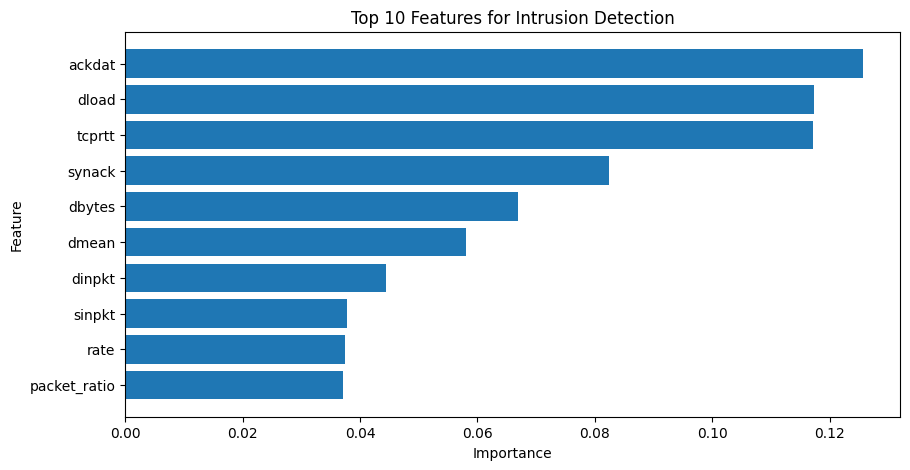

In [ ]:
import matplotlib.pyplot as plt

top10 = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Intrusion Detection")
plt.gca().invert_yaxis()
plt.show()

# PCA Visualization

**Reduce the network traffic to 2 dimensions and visualize attacks vs normal traffic.**

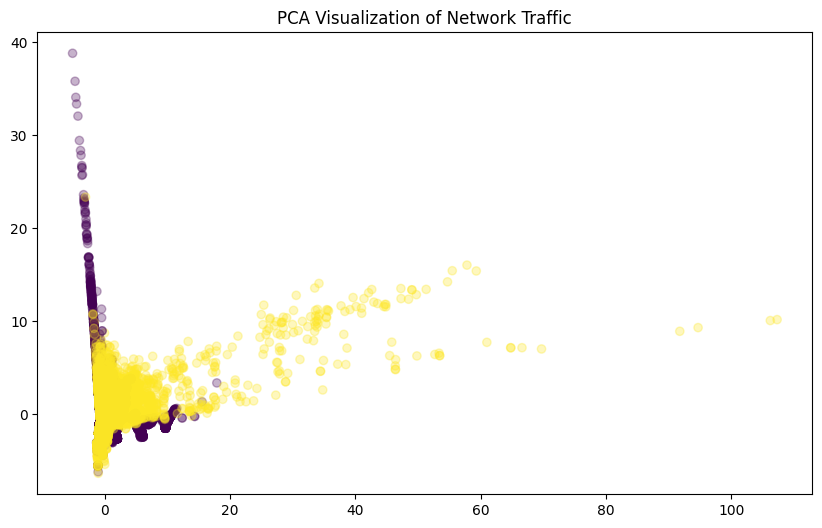

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_std)

plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    alpha=0.3
)

plt.title("PCA Visualization of Network Traffic")
plt.show()

# PCA Visualization

**To see which attacks are hardest to detect.**

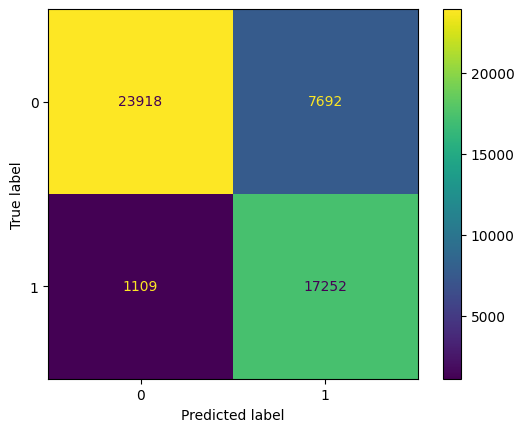

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

# ROC Curve

**This is a standard security metric.**

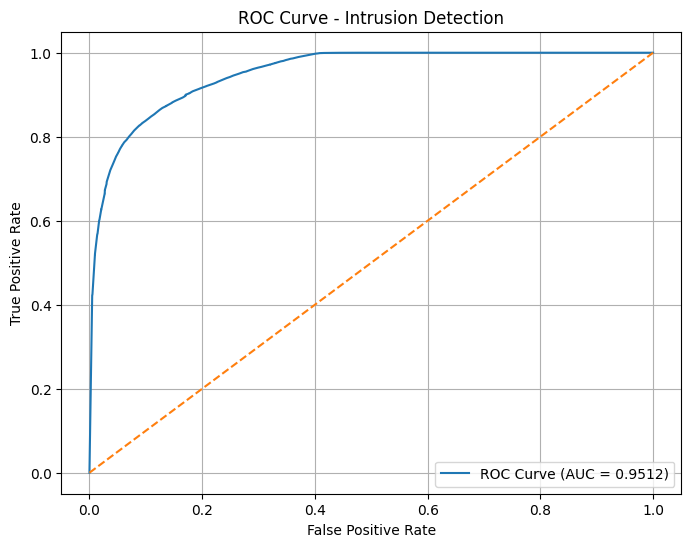

AUC Score: 0.9512096823451204


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_probs = rf.predict_proba(X_test_std)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Intrusion Detection')
plt.legend()
plt.grid(True)

plt.show()

print("AUC Score:", roc_auc)

In [ ]:
from sklearn.metrics import classification_report

pred = rf.predict(X_test_std)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.76      0.84     31610
           1       0.69      0.94      0.80     18361

    accuracy                           0.82     49971
   macro avg       0.82      0.85      0.82     49971
weighted avg       0.86      0.82      0.83     49971



In [ ]:
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label,total_bytes,total_packets,bytes_per_packet,packet_ratio
0,0.121478,113,0,2,6,4,258,172,74.087486,14158.942383,...,0,0,0,0,Normal,0,430,10,39.090909,1.200000
1,0.649902,113,0,2,14,38,734,42014,78.473373,8395.112305,...,0,0,0,0,Normal,0,42748,52,806.566038,0.358974
2,1.623129,113,0,2,8,16,364,13186,14.170161,1572.271851,...,0,0,0,0,Normal,0,13550,24,542.000000,0.470588
3,1.681642,113,3,2,12,12,628,770,13.677108,2740.178955,...,1,1,0,0,Normal,0,1398,24,55.920000,0.923077
4,0.449454,113,0,2,10,6,534,268,33.373825,8561.499023,...,0,0,0,0,Normal,0,802,16,47.176471,1.428571


# Feature Selection

In [ ]:
print(selected_features)

Index(['dur', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'total_bytes', 'total_packets', 'bytes_per_packet',
       'packet_ratio'],
      dtype='object')


In [ ]:
print(X_train.shape)
print(X_train_selected.shape)

(96822, 38)
(96822, 20)


In [ ]:
X_train.describe()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,total_bytes,total_packets,bytes_per_packet,packet_ratio
count,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,9.682200e+04,9.682200e+04,96822.000000,9.682200e+04,...,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,96822.000000,9.682200e+04,96822.000000,96822.000000,96822.000000
mean,1.492981,111.124961,2.009874,1.906819,33.343155,33.400498,1.534994e+04,2.640205e+04,21616.699219,3.673790e+07,...,1.718721,1.205573,0.019200,0.019200,0.200709,0.005205,4.175199e+04,66.743653,227.364900,1.668271
std,5.765602,15.115909,2.871762,0.791289,182.663081,143.654676,2.348021e+05,1.882358e+05,86625.593750,1.964549e+08,...,2.656315,1.282107,0.139246,0.139246,0.601968,0.071961,3.018464e+05,272.234243,246.557442,6.333095
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.800000e+01,1.000000,14.000000,0.002497
25%,0.017723,113.000000,0.000000,2.000000,8.000000,6.000000,5.640000e+02,2.680000e+02,24.589354,8.312729e+03,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.180000e+02,16.000000,64.800000,0.869565
50%,0.444509,113.000000,0.000000,2.000000,10.000000,8.000000,1.048000e+03,6.980000e+02,63.841385,3.635026e+04,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.176000e+03,20.000000,98.666667,1.111111
75%,1.019829,113.000000,5.000000,2.000000,24.000000,22.000000,2.958000e+03,3.674000e+03,2832.861084,6.434555e+05,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.185200e+04,48.000000,359.151515,1.428571
max,59.999989,132.000000,12.000000,8.000000,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,...,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.472678e+07,12628.000000,1284.857143,512.000000


In [ ]:
pd.DataFrame(X_train_std).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,96822.000000,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04,9.682200e+04
mean,-2.583205e-17,-7.045104e-18,-5.870920e-19,-1.174184e-17,-1.761276e-17,1.174184e-18,5.166409e-17,1.643858e-17,0.000000,-1.174184e-18,-4.843509e-18,2.348368e-17,-1.878694e-17,1.080249e-16,4.461899e-17,-9.158635e-17,7.045104e-18,1.497085e-17,3.933516e-17,1.291602e-17
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-2.589529e-01,-2.325067e-01,-6.525505e-02,-1.402612e-01,-2.495709e-01,-1.870572e-01,-3.804541e-01,-1.007234e-01,-0.101962,-1.418084e-01,-1.800958e-01,-7.508727e-01,-6.856607e-01,-7.187926e-01,-5.861046e-01,-6.910508e-01,-1.382299e-01,-2.414979e-01,-8.653805e-01,-2.630282e-01
25%,-2.558788e-01,-1.907396e-01,-6.297226e-02,-1.388375e-01,-2.492870e-01,-1.870149e-01,-3.795131e-01,-1.006082e-01,-0.101644,-1.412963e-01,-1.798191e-01,-7.445527e-01,-6.766679e-01,-7.163930e-01,-4.646752e-01,-5.478432e-01,-1.352814e-01,-1.863980e-01,-6.593423e-01,-1.261168e-01
50%,-1.818543e-01,-1.768173e-01,-6.091094e-02,-1.365531e-01,-2.488338e-01,-1.868721e-01,-3.772970e-01,-9.436390e-02,-0.074983,-1.032032e-01,-1.639177e-01,-7.370739e-01,-6.645682e-01,-7.136387e-01,-3.706654e-01,-4.364596e-01,-1.311137e-01,-1.717047e-01,-5.219834e-01,-8.797638e-02
75%,-8.206680e-02,-7.936085e-02,-5.277639e-02,-1.207431e-01,-2.168647e-01,-1.837809e-01,-1.861663e-01,-8.300839e-02,-0.024094,-2.912642e-02,-1.394428e-01,6.594620e-01,6.204527e-01,5.599746e-01,-1.787287e-01,-1.182205e-01,-9.905749e-02,-6.885155e-02,5.345095e-01,-3.784892e-02
max,1.014786e+01,7.615941e+01,5.515262e+01,7.771754e+01,1.129571e+01,3.030185e+01,6.718719e+00,1.866152e+01,49.750265,3.508357e+01,5.715201e+01,2.627694e+01,3.984665e+01,3.101583e+01,5.195499e+00,3.948875e+00,4.865093e+01,4.614159e+01,4.289052e+00,8.058215e+01
